# Exon Inclusion Analysis

In [1]:
!pip install ipykernel
!python -m ipykernel install --user --name finalproject --display-name "Python (final project)"

Installed kernelspec finalproject in /home/biouser/.local/share/jupyter/kernels/finalproject


In [2]:
## 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.stats import spearmanr, bootstrap
from gtfparse import read_gtf
import pysam  
from matplotlib.colors import LinearSegmentedColormap
from functions import (
    load_type_neurons,
    compute_spearman_corr,
    spearman_corr_labels,
)

## 1. Load Data
- Load `altExonUsage_devel_type.gz`
- Filter only column with `Neuron` 
- Combine `Exon` and `Gene` to `GE` (`Exon::Gene`)

In [3]:
type_neurons = load_type_neurons("../../data/altExonUsage_devel_type.gz")
type_neurons.head(20)

,P14_Hippocampus_ExciteNeuron,P14_Hippocampus_InhibNeuron,P14_VisCortex_ExciteNeuron,P14_VisCortex_InhibNeuron,P21_Hippocampus_ExciteNeuron,P21_Hippocampus_InhibNeuron,P21_VisCortex_ExciteNeuron,P21_VisCortex_InhibNeuron,P28_Hippocampus_ExciteNeuron,P28_Hippocampus_InhibNeuron,P28_VisCortex_ExciteNeuron,P28_VisCortex_InhibNeuron,P56_Hippocampus_ExciteNeuron,P56_Hippocampus_InhibNeuron,P56_VisCortex_ExciteNeuron,P56_VisCortex_InhibNeuron
GE,,,,,,,,,,,,,,,,
chr1_162273620_162273649_-::ENSMUSG00000040265.16,0.032520,0.000000,0.008152,0.000000,0.049351,0.024000,0.000000,0.000000,0.015544,0.007812,0.001163,0.000000,0.015831,0.026316,0.005181,0.001821
chr1_186690721_186690804_-::ENSMUSG00000039239.14,0.000000,NaN,NaN,NaN,0.075472,NaN,NaN,NaN,0.083333,NaN,NaN,NaN,0.139073,NaN,0.019608,0.125000
chr1_172286198_172286396_-::ENSMUSG00000007097.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.818182,NaN
chr1_83384894_83384972_-::ENSMUSG00000026163.17,0.608364,0.642140,0.707604,0.657718,0.631307,0.707113,0.767779,0.776471,0.670919,0.666667,0.789824,0.805970,0.641826,0.694915,0.781662,0.712150
chr1_172279313_172279467_-::ENSMUSG00000007097.14,1.000000,NaN,1.000000,NaN,0.823529,NaN,0.823529,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,0.965517,NaN
chr1_163253977_163254048_-::ENSMUSG00000026586.16,0.545455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chr1_172287200_172287468_-::ENSMUSG00000007097.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chr1_16486020_16486150_-::ENSMUSG00000025920.19,0.204724,0.032967,0.240229,0.097222,0.222116,0.230769,0.275465,0.102564,0.223958,0.000000,0.230177,0.132075,0.218418,0.050633,0.220895,0.145867
chr1_162675605_162675841_-::ENSMUSG00000040225.15,0.812834,0.714286,0.824022,0.848485,0.891247,0.795455,0.818493,0.914286,0.869822,1.000000,0.841040,NaN,0.950530,0.840000,0.900850,0.959184


## 2. Performn Pairwise Correlation

- Remove rows with missing data `NaN`
- Compute Spearman correlation matrix

In [4]:
CN = compute_spearman_corr(type_neurons)
CN

,P14_HIPP_Excite,P14_HIPP_Inhib,P14_VIS_Excite,P14_VIS_Inhib,P21_HIPP_Excite,P21_HIPP_Inhib,P21_VIS_Excite,P21_VIS_Inhib,P28_HIPP_Excite,P28_HIPP_Inhib,P28_VIS_Excite,P28_VIS_Inhib,P56_HIPP_Excite,P56_HIPP_Inhib,P56_VIS_Excite,P56_VIS_Inhib
P14_HIPP_Excite,1.000000,0.884217,0.962237,0.899971,0.971003,0.868121,0.947010,0.860983,0.949210,0.850278,0.943170,0.880083,0.961826,0.902950,0.934050,0.886542
P14_HIPP_Inhib,0.884217,1.000000,0.878134,0.910373,0.870207,0.916648,0.853516,0.846149,0.863946,0.909185,0.855788,0.883274,0.869281,0.925440,0.854794,0.904063
P14_VIS_Excite,0.962237,0.878134,1.000000,0.925685,0.954540,0.876602,0.964306,0.877206,0.928853,0.850946,0.958362,0.900242,0.935769,0.900521,0.946463,0.906316
P14_VIS_Inhib,0.899971,0.910373,0.925685,1.000000,0.890136,0.889708,0.888126,0.880438,0.871564,0.882559,0.886951,0.917194,0.883123,0.912734,0.880189,0.913409
P21_HIPP_Excite,0.971003,0.870207,0.954540,0.890136,1.000000,0.886830,0.973686,0.887591,0.968928,0.860166,0.964302,0.892825,0.981593,0.917818,0.965583,0.909689
P21_HIPP_Inhib,0.868121,0.916648,0.876602,0.889708,0.886830,1.000000,0.892030,0.904615,0.879264,0.911842,0.881864,0.912125,0.874085,0.931539,0.885403,0.941667
P21_VIS_Excite,0.947010,0.853516,0.964306,0.888126,0.973686,0.892030,1.000000,0.912379,0.950948,0.858103,0.980269,0.900454,0.952490,0.905970,0.983004,0.925432
P21_VIS_Inhib,0.860983,0.846149,0.877206,0.880438,0.887591,0.904615,0.912379,1.000000,0.883744,0.859579,0.891405,0.899474,0.874334,0.891868,0.899297,0.925791
P28_HIPP_Excite,0.949210,0.863946,0.928853,0.871564,0.968928,0.879264,0.950948,0.883744,1.000000,0.874911,0.966287,0.884917,0.970060,0.912727,0.951848,0.906948
P28_HIPP_Inhib,0.850278,0.909185,0.850946,0.882559,0.860166,0.911842,0.858103,0.859579,0.874911,1.000000,0.863372,0.891848,0.856964,0.916498,0.858614,0.912753


## 3. Heat Map of Pairwise Correlation for Excitatory and Inhibitory Types

- Extract metadata from the table's index to create labels for the heat map
    - `Age`, `Region`, `Type` 
- Create colour palettes for each label
- Create a cluster map
    - Dendrogram of excitatory type & inhitory type
    - Heat map of Spearman pairwise correlations of exon inclusion for each cell type 

In [5]:
# Create labels for the heatmap
cnn = spearman_corr_labels(CN)
cnn

,CT,Age,Region,Type
0,P14_HIPP_Excite,P14,HIPP,Excite
1,P14_HIPP_Inhib,P14,HIPP,Inhib
2,P14_VIS_Excite,P14,VIS,Excite
3,P14_VIS_Inhib,P14,VIS,Inhib
4,P21_HIPP_Excite,P21,HIPP,Excite
5,P21_HIPP_Inhib,P21,HIPP,Inhib
6,P21_VIS_Excite,P21,VIS,Excite
7,P21_VIS_Inhib,P21,VIS,Inhib
8,P28_HIPP_Excite,P28,HIPP,Excite
9,P28_HIPP_Inhib,P28,HIPP,Inhib


In [ ]:
## Define colour palettes

# Ages 
ages = ["P14", "P21", "P28", "P56"]
ages_colour = ["#ae3b24", "#c8812a", "#56632c" ,"#f68d62"]
ages_palette = dict(zip(ages, ages_colour))

# Regions
regions = ["VIS", "HIPP"]
regions_colour = ["#ddbbc6", "#fdc681"]
regions_palette = dict(zip(regions, regions_colour))

# Cell types
cts = ["Excite", "Inhib"]
cts_colour = ["#ffcc5c", "#65c3ba"]
cts_palette = dict(zip(cts, cts_colour))

{'Excite': '#ffcc5c', 'Inhib': '#65c3ba'}

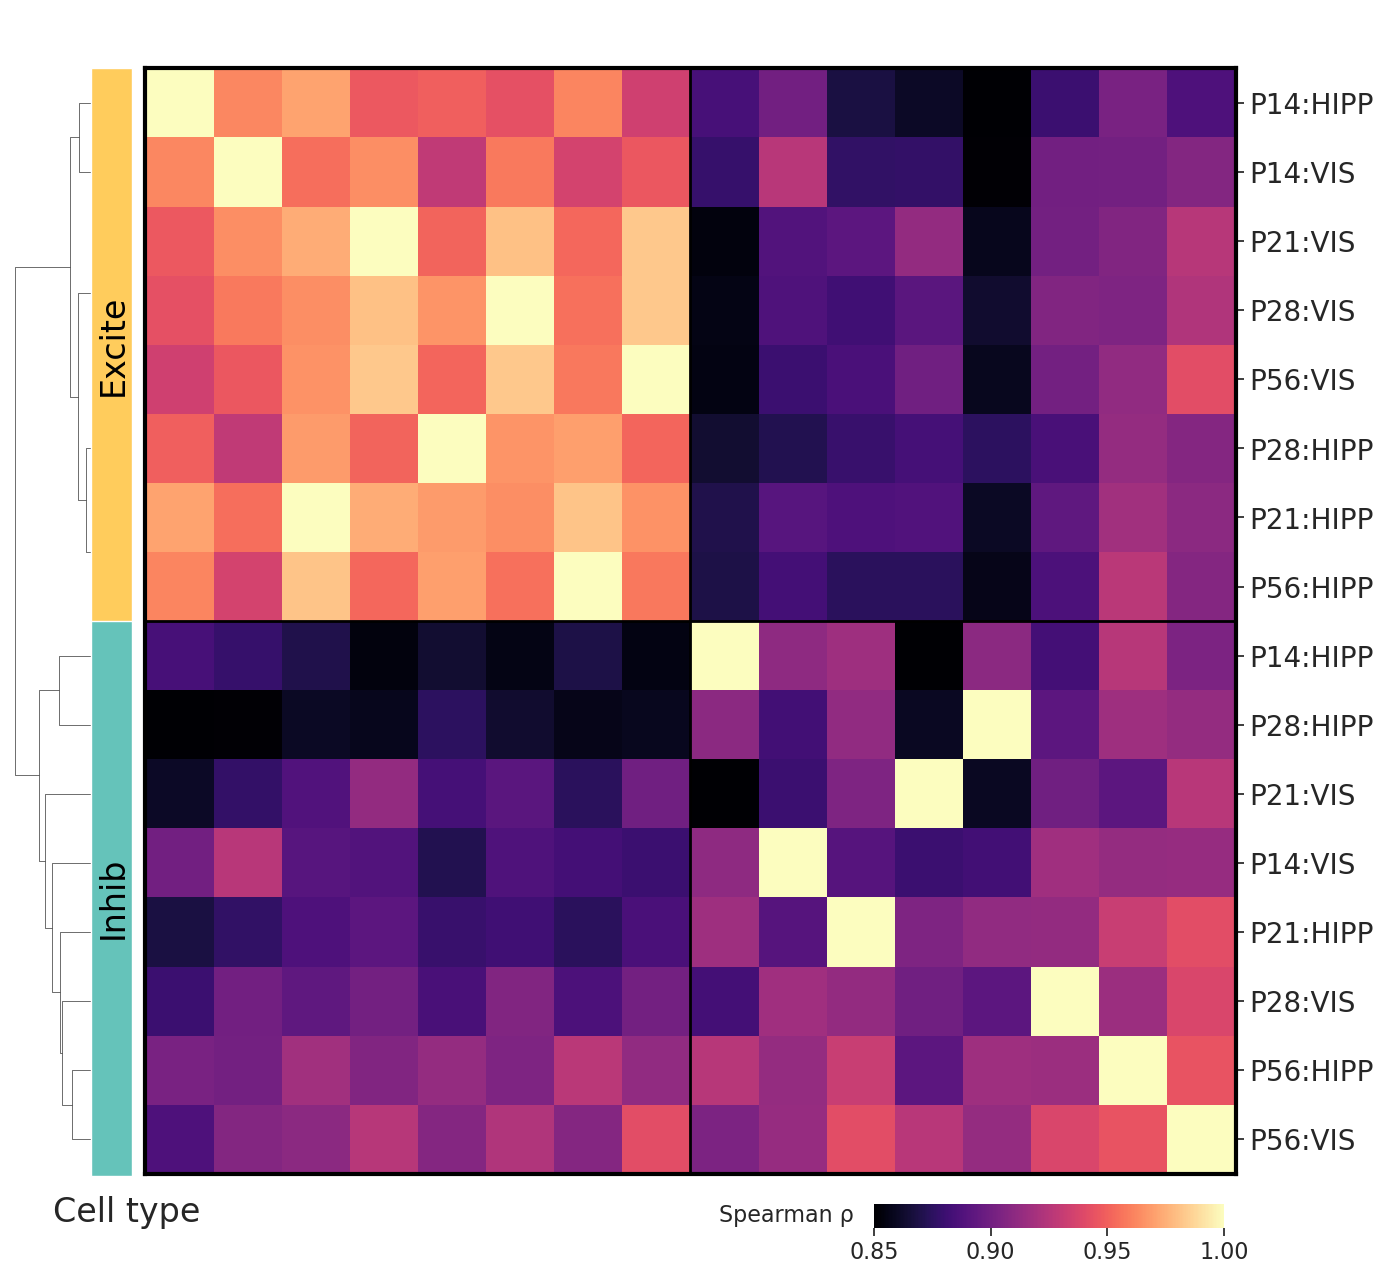

In [551]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch
from matplotlib.patches import Rectangle

# Prepare row order
excite = cnn[cnn["Type"] == "Excite"]["CT"].tolist()
inhib  = cnn[cnn["Type"] == "Inhib"]["CT"].tolist()

row_order = excite + inhib
CN2 = CN.loc[row_order, row_order]

np.fill_diagonal(CN2.values, 1.0)

# Create masked correlation 
CN_masked = CN2.copy()

# Set cross-type correlations LOW
for r in excite:
    for c in inhib:
        CN_masked.loc[r, c] = 0
        CN_masked.loc[c, r] = 0

# Force symmetry and diagonal 
CN_masked = (CN_masked + CN_masked.T) / 2
np.fill_diagonal(CN_masked.values, 1)

# Convert correlation → distance
dist = 1 - CN_masked

# Linkage 2 clusters
condensed = squareform(dist.values, checks=True)
Z = sch.linkage(condensed, method="complete", optimal_ordering=True)

# Side colour labels
row_colours = pd.Series(row_order).map(
    lambda ct: cts_palette["Excite"] if ct in excite else cts_palette["Inhib"]
)

# Clustermap 
sns.set_theme(style="white")

g = sns.clustermap(
    CN2,
    figsize=(14, 12),
    row_colors=row_colours,
    col_cluster=False,
    cmap="magma",
    vmin=0.85,
    vmax=1.0,
    dendrogram_ratio=(0.08, 0.05),
    cbar_kws= {"orientation": "horizontal", "ticks" : [0.85, 0.9, 0.95, 1.0]},
    cbar_pos=(0.63, -0.03, 0.25, 0.02),
    xticklabels=False,
    yticklabels=True,
)

# Rename y-tick labels -> Age:Region
ylabels = []
for ct in g.data2d.index:
    row = cnn.loc[cnn["CT"] == ct].iloc[0]
    label = f"{row['Age']}:{row['Region']}"
    ylabels.append(label)

g.ax_heatmap.set_yticklabels(ylabels, fontsize=20)

# Add border
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(3)
    spine.set_color("black")

# Add cluster border line
n_excite = len(excite)
g.ax_heatmap.axhline(n_excite, color="black", linewidth=2)
g.ax_heatmap.axvline(n_excite, color="black", linewidth=2)

# Add cluster labels
ax = g.ax_heatmap

# Excite
ax.text(-0.47, n_excite/2, "Excite",
        rotation=90,
        va="center",
        ha="center",
        fontsize=24,
        color="black",
)

# Inhib
ax.text(-0.47, n_excite + (len(inhib)/2), "Inhib",
        rotation=90,
        va="center",
        ha="center",
        fontsize=24,
        color="black",
)

# Add rectangular colour blocks for cluster labels
ax.add_patch(Rectangle(
    (-0.8, 0),
    0.6,
    n_excite + 0.03,
    transform=ax.transData,
    facecolor=cts_palette["Excite"],
    clip_on=False
))

ax.add_patch(Rectangle(
    (-0.8, n_excite),
    0.6,
    len(inhib) + 0.03,
    transform=ax.transData,
    facecolor=cts_palette["Inhib"],
    clip_on=False
))

g.ax_heatmap.set_ylabel(None)
g.ax_heatmap.text(
    -1.35, 16.8,
    "Cell type",
    va="bottom",
    ha="left",
    fontsize=24,
)

# Add colour bar
cbar = g.cax
cbar.set_ylabel(None)
cbar.text(
    -0.25, 0.03,               # position (x,y) inside colorbar axis
    "Spearman ρ",             # label text
    va="bottom",
    ha="center",
    fontsize=16,
    transform=cbar.transAxes,
)

# Increase tick label font size
for tick in cbar.get_xticklabels():
    tick.set_fontsize(16)

plt.savefig("../plots/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Box Plot of Pairwise Correlation for Excitatory and Inhibitory Types

/tmp/ipykernel_350395/396290429.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


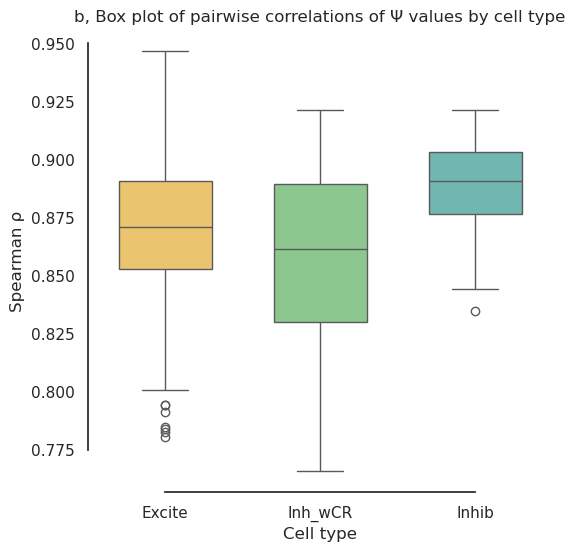

In [496]:
tmp_mat_excite = CN.filter(like="Excite", axis=1)           
tmp_mat_excite = tmp_mat_excite.loc[[i for i in CN.index if "Excite" in i]]  
CE = tmp_mat_excite.values[np.triu_indices_from(tmp_mat_excite, k=1)]         #

# Inhib correlations (upper triangle only)
tmp_mat_inhib = CN.filter(like="Inhib", axis=1)
tmp_mat_inhib = tmp_mat_inhib.loc[[i for i in CN.index if "Inhib" in i]]
CI = tmp_mat_inhib.values[np.triu_indices_from(tmp_mat_inhib, k=1)]

df = pd.DataFrame({
    "CorValue": np.concatenate([CE, CI]),
    "Type": ["Excite"]*len(CE) + ["Inhib"]*len(CI)
})

# -----------------------------
# Step 3: Read in subtype PSI values
# -----------------------------
subtype_alt = pd.read_csv('../../data/altExonUsage_devel_subtype.gz', sep="\t", header=0)

# Select only neuron-related columns and combine Exon and Gene as row index
cols_to_keep = [c for c in subtype_alt.columns if any(x in c for x in ["Excite","Inh","Granule","NIPC"])]
subtype_neurons = subtype_alt[["Exon","Gene"] + cols_to_keep].copy()
subtype_neurons.index = subtype_neurons["Exon"] + "::" + subtype_neurons["Gene"]
subtype_neurons = subtype_neurons.drop(columns=["Exon","Gene"])

# -----------------------------
# Step 4: Filter based on missing data thresholds
# -----------------------------
threshold = 0.95
subtype_neurons2 = subtype_neurons.loc[:, subtype_neurons.isna().mean() < threshold]
subtype_neurons2 = subtype_neurons2.loc[subtype_neurons2.isna().mean(axis=1) <= threshold, :]

# -----------------------------
# Step 5: Compute Spearman correlations
# -----------------------------
C_st_N = subtype_neurons2.corr(method="spearman")

# -----------------------------
# Step 6: Separate Excite, Inhib, and Inh with Cajal Retzius (CR)
# -----------------------------
# Separate into Excite, Inh, Inh_wCR
tmp_excite = C_st_N.filter(like="Excite").loc[C_st_N.index.str.contains("Excite")]
CE = tmp_excite.values[np.triu_indices_from(tmp_excite, k=1)]

tmp_inhib_all = C_st_N.filter(like="Inhib").loc[C_st_N.index.str.contains("Inhib")]
CI = tmp_inhib_all.values[np.triu_indices_from(tmp_inhib_all, k=1)]

tmp_inh_wcr = C_st_N.filter(like="Inh").loc[C_st_N.index.str.contains("Inh")]
CR = tmp_inh_wcr.values[np.triu_indices_from(tmp_inh_wcr, k=1)]

# Combine into a DataFrame
df = pd.DataFrame({
    "CorValue": np.concatenate([CE, CR, CI]),
    "Type": ["Excite"]*len(CE) + ["Inh_wCR"]*len(CR) + ["Inhib"]*len(CI)
})

# Ensure the order
df["Type"] = pd.Categorical(df["Type"], categories=["Excite", "Inh_wCR", "Inhib"], ordered=True)

# -----------------------------
# Plot horizontal boxplot
# -----------------------------
plt.figure(figsize=(6,6))
sns.boxplot(
    data=df,
    x="Type",
    y="CorValue",   
    palette=["#ffcc5c","#82d188","#65c3ba"],
    width=0.6
)
plt.ylabel("Spearman ρ")
plt.xlabel("Cell type")
plt.title("b, Box plot of pairwise correlations of Ψ values by cell type", fontsize=12)
sns.despine(trim=True)
plt.savefig("../plots/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
row_order

['P14_HIPP_Excite',
 'P14_VIS_Excite',
 'P28_VIS_Excite',
 'P21_VIS_Excite',
 'P56_VIS_Excite',
 'P28_HIPP_Excite',
 'P21_HIPP_Excite',
 'P56_HIPP_Excite',
 'P21_VIS_Inhib',
 'P14_VIS_Inhib',
 'P28_VIS_Inhib',
 'P14_HIPP_Inhib',
 'P28_HIPP_Inhib',
 'P21_HIPP_Inhib',
 'P56_HIPP_Inhib',
 'P56_VIS_Inhib']

In [15]:
excite_order, Z_excite

(['P14_HIPP_Excite',
  'P14_VIS_Excite',
  'P28_VIS_Excite',
  'P21_VIS_Excite',
  'P56_VIS_Excite',
  'P28_HIPP_Excite',
  'P21_HIPP_Excite',
  'P56_HIPP_Excite'],
 array([[ 3.        ,  7.        ,  0.01699574,  2.        ],
        [ 2.        ,  6.        ,  0.01840722,  2.        ],
        [ 5.        ,  8.        ,  0.01973103,  3.        ],
        [ 4.        ,  9.        ,  0.03107176,  3.        ],
        [ 0.        ,  1.        ,  0.0377631 ,  2.        ],
        [10.        , 11.        ,  0.04905224,  6.        ],
        [12.        , 13.        ,  0.07114656,  8.        ]]))

In [18]:
inhib_order, Z_inhib

(['P21_VIS_Inhib',
  'P14_VIS_Inhib',
  'P28_VIS_Inhib',
  'P14_HIPP_Inhib',
  'P28_HIPP_Inhib',
  'P21_HIPP_Inhib',
  'P56_HIPP_Inhib',
  'P56_VIS_Inhib'],
 array([[ 6.        ,  7.        ,  0.05520426,  2.        ],
        [ 2.        ,  8.        ,  0.06846081,  3.        ],
        [ 1.        ,  5.        ,  0.08280602,  2.        ],
        [ 4.        ,  9.        ,  0.08815829,  4.        ],
        [ 0.        , 11.        ,  0.09593718,  5.        ],
        [10.        , 12.        ,  0.11744125,  7.        ],
        [ 3.        , 13.        ,  0.1538508 ,  8.        ]]))